In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
%matplotlib notebook
import random as rand
import multiprocessing as mp
from tqdm import tqdm
from runtumble import Cell, Wall, RTP, Ball

In [4]:
c = Cell()
N = 50 # The number of RNT particles to simulate
p = []
for i in range(N):
    p.append(RTP())
for particle in p:
    particle.r = np.array((rand.random() * c.cell_size[0], rand.random() * c.cell_size[1]))
    c.add_particle(particle)
b = Ball(7.5,7.5,3,0.5) # ball's (x, y, mass, radius)
c.add_particle(b)
p.append(b)

In [5]:
c.set_field(0) # The field strength
c.set_pbc(True) # Periodic boundary conditions
c.set_velocity(0.5) # Intrinsic particle velocity
c.set_decay_rate(0.5) # Particle decay rate
c.set_RTP_radius(0.1)

In [6]:
def ball_path(N, dt=0.1):
    b.x, b.y = (rand.random() * (c.cell_size[0] - 1) + 0.5, rand.random() * (c.cell_size[1] - 1) + 0.5) 
    for rtp in c.get_RTPs():
        rtp.x, rtp.y = ((rand.random() * (c.cell_size[0] - 0.2) + 0.1, rand.random() * (c.cell_size[1] - 0.2) + 0.1))
        rtp.tumble()
    c.left_flux = c.right_flux = 0
    path = []
    for i in range(N):
#         print(b.r)
        path.append((b.x, b.y))
        c.advance(dt)
        print(f'{i+1:>5d}', end='\r')
    return np.array(path).T

In [8]:
path = ball_path(5000)
print(f'{c.left_flux}, {c.right_flux}')

189, 188


In [39]:
path

array([[7.5       , 7.51770891, 7.53541782, ..., 2.10326578, 2.08987241,
        2.07647904],
       [7.5       , 7.5       , 7.5       , ..., 0.505     , 0.505     ,
        0.505     ]])

<IPython.core.display.Javascript object>


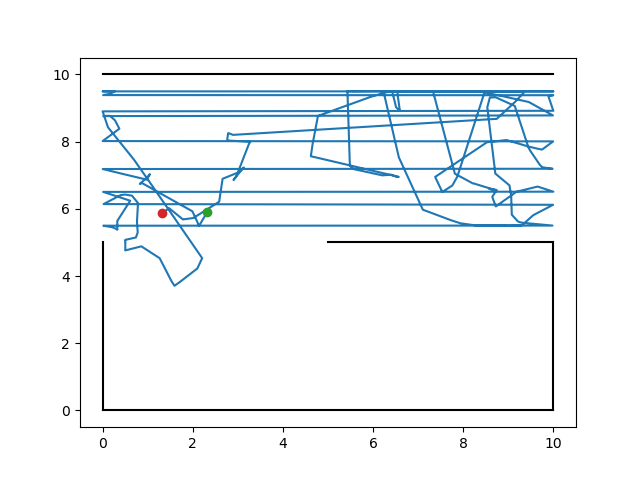

In [9]:
plt.figure()

plt.plot(path[0], path[1])
plt.scatter(path[0][0], path[1][0], color='C2', zorder=5)
plt.scatter(path[0][-1], path[1][-1], color='C3', zorder=5)
for w in c.get_walls():
    w.draw(plt.gca())

In [10]:
fig, ax = plt.subplots()
line, = ax.plot(path[0], path[1], color='k')

for w in c.get_walls():
    w.draw(ax)

def update(num, path, line):
    line.set_data(path[0][:num], path[1][:num])
    return line,

ani = animation.FuncAnimation(fig, update, len(path[0]), fargs=[path, line],
                              interval=25, blit=False)
plt.show()

<IPython.core.display.Javascript object>

In [31]:
def density_sim(num_sim, num_step, dt=0.1):
    positions = []
    for j in range(num_sim):
        b.x, b.y = (rand.random() * (c.cell_size[0] - 1) + 0.5, rand.random() * (c.cell_size[1] - 1) + 0.5) 
        for rtp in c.get_RTPs():
            rtp.x, rtp.y = ((rand.random() * (c.cell_size[0] - 0.2) + 0.1, rand.random() * (c.cell_size[1] - 0.2) + 0.1))
            rtp.tumble()
#         c.left_flux = c.right_flux = 0
        for i in range(num_step):
            positions.append((b.x, b.y))
            c.advance(dt)
            print(f"{j+1:>4d}: {i+1:>5d}", end='\r')
    return np.array(positions).T

In [45]:
positions = density_sim(100, 5000)

  86:  2948

/home/simon/git/RTPython/runtumble.py:646: RuntimeWarning: invalid value encountered in true_divide
  alpha = acos(dot(r, v_r/norm(v_r)))
/home/simon/git/RTPython/runtumble.py:649: RuntimeWarning: invalid value encountered in true_divide
  rtp.v = self.v + norm(v_r) * sin(alpha) * dot(v_r/norm(v_r), t) * t


In [28]:
positions

array([[7.18840095, 7.19226751, 7.19613406, ..., 6.97405425, 6.95905215,
        6.94405005],
       [7.88392351, 7.88558605, 7.8872486 , ..., 9.495     , 9.495     ,
        9.495     ]])

<IPython.core.display.Javascript object>


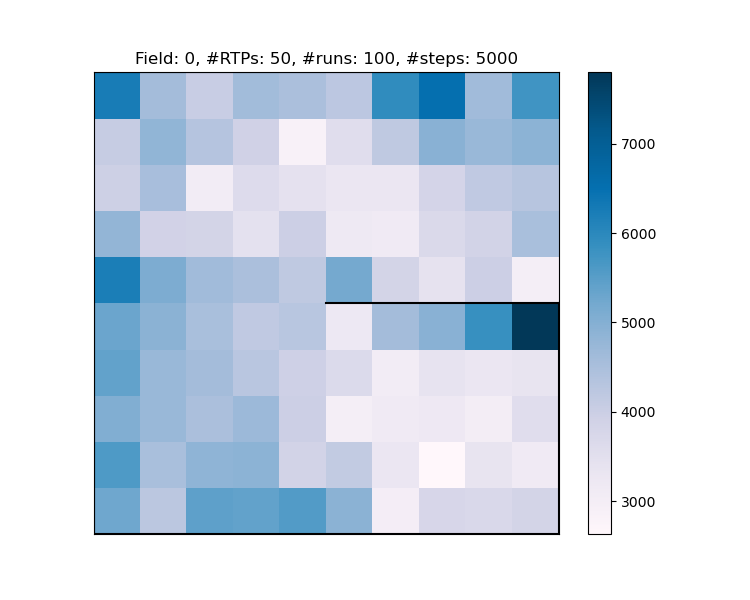

In [64]:
plt.figure(figsize=(7.5,6))

plt.title(f'Field: 0, #RTPs: 50, #runs: 100, #steps: 5000')
plt.xticks([])
plt.yticks([])
plt.hist2d(positions[0], positions[1], cmap='PuBu', bins=[10,10], range=[[0, 10], [0, 10]])
plt.colorbar()
for w in c.get_walls():
    w.draw(plt.gca())
# plt.savefig('ball_density_0_50_100_500_10x10.png', dpi=300)

In [ ]:
np.savetxt('ball_density_0_50_100_500.txt', posi)

In [11]:
import cProfile
cProfile.run('ball_path(5000)')